IDENTITAS: **MARISSA AUDITIA KHOIRONISA**





Tujuan analisis model

Analisis ini bertujuan untuk membangun model machine learning yang mampu memprediksi Revenue Potential produk parfum berdasarkan fitur-fitur seperti merek (Brand), negara asal (Country), kategori harga (Price_Category), segmen pasar (Market_Segment), performa penjualan (Sales_Performance), popularitas merek (Brand_Popularity), ketersediaan stok (Available), dan rotasi stok (Stock_Turnover).

Berdasarkan informasi tersebut, model dapat memberikan pendapatan yang lebih tinggi

Problem Statement

Berdasarkan latar belakang tersebut, permasalahan yang ingin diselesaikan dalam proyek ini adalah:

1. Bagaimana karakteristik data memengaruhi Revenue Potential suatu produk?
Karakteristik data dianalisis melalui proses Exploratory Data Analysis (EDA) untuk memahami distribusi data, tipe data, nilai yang hilang (missing values), outlier, serta hubungan antar variabel. Analisis ini bertujuan memastikan kualitas data sebelum dilakukan tahap preprocessing dan pemodelan sehingga model yang dibangun dapat menghasilkan prediksi yang lebih akurat.


2. Faktor apa saja yang memiliki hubungan paling kuat terhadap Revenue Potential?
Pengaruh setiap fitur dianalisis menggunakan statistik deskriptif, visualisasi data, dan analisis korelasi. Hasil analisis digunakan untuk mengidentifikasi fitur-fitur yang memiliki hubungan paling kuat terhadap Revenue_Potential.
Fitur yang memiliki korelasi paling kuat adalah Demand_Score


3. Algoritma Machine Learning manakah yang memberikan performa terbaik dalam memprediksi Revenue Potential?
Model Ridge Regression dan Random Forest Regressor akan dibandingkan berdasarkan metrik evaluasi seperti R² Score, RMSE, MAE, dan MAPE. Model dengan nilai R² tertinggi serta nilai RMSE, MAE, dan MAPE terendah akan dipilih sebagai model terbaik karena memiliki kemampuan yang lebih baik dalam memprediksi Revenue_Potential.
Di antara keduanya algoritma yang memiliki performa terbaik adalah  Random Forest Regressor



In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, OneHotEncoder, OrdinalEncoder, PowerTransformer
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

import joblib, os


# **Data Loading & Pengecekan Awal**

In [ ]:
!kaggle datasets download zohairbaloch/global-perfume-e-commerce-analytics-dataset

Dataset URL: https://www.kaggle.com/datasets/zohairbaloch/global-perfume-e-commerce-analytics-dataset
License(s): unknown
100% 101k/101k [00:00<00:00, 96.6MB/s]



In [ ]:
!unzip -o -q /content/global-perfume-e-commerce-analytics-dataset.zip

In [ ]:
df = pd.read_csv('/content/Perfume_Market_Intelligence_Dataset.csv')
df.head()

,Brand,Product,Gender,Product_Type,Price,Sold,Available,Revenue_Potential,Demand_Score,Price_Category,Market_Segment,Sales_Performance,Brand_Popularity,Country,Inventory_Status,Stock_Turnover,Revenue_Rank
0,Paco Rabanne,Paco Rabanne Invictus 3.4 oz EDT Sporty Men's ...,Men,EDT,39.99,118.0,10.0,4718.82,94.597,Mid-Range,Premium,High Seller,High,United States,Medium Stock,Fast,Others
1,Lucianno,Lucianno California Vibe M 100ml Boxed,Men,Unknown,66.00,21.0,10.0,1386.00,34.500,Mid-Range,Premium,Medium Seller,Low,Canada,Medium Stock,Slow,Others
2,BHARARA,BHARARA KING PURE PARFUM BY BHARARA 3.4 FOR ME...,Men,Parfum,71.49,31.0,4.0,2216.19,43.147,Mid-Range,Premium,Medium Seller,Low,United States,Low Stock,Fast,Others
3,Branded,*Perfume Para Hombre Con Feromonas De Atraer M...,Men,Unknown,17.99,1.0,13.0,17.99,6.097,Budget,Mass Market,Low Seller,Low,United States,Medium Stock,Slow,Others
4,Thierry Mugler,Alien by Thierry Mugler 3 oz EDP Perfume for W...,Women,EDP,85.56,953.0,0.0,81538.68,692.768,Luxury,Luxury,High Seller,Medium,United States,Low Stock,Fast,Top 10%


In [ ]:
df.shape

(1998, 17)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1998 entries, 0 to 1997
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Brand              1996 non-null   object 
 1   Product            1998 non-null   object 
 2   Gender             1998 non-null   object 
 3   Product_Type       1998 non-null   object 
 4   Price              1998 non-null   float64
 5   Sold               1998 non-null   float64
 6   Available          1998 non-null   float64
 7   Revenue_Potential  1998 non-null   float64
 8   Demand_Score       1998 non-null   float64
 9   Price_Category     1998 non-null   object 
 10  Market_Segment     1998 non-null   object 
 11  Sales_Performance  1998 non-null   object 
 12  Brand_Popularity   1998 non-null   object 
 13  Country            1998 non-null   object 
 14  Inventory_Status   1998 non-null   object 
 15  Stock_Turnover     1998 non-null   object 
 16  Revenue_Rank       1998 

VISUALISASI DATA

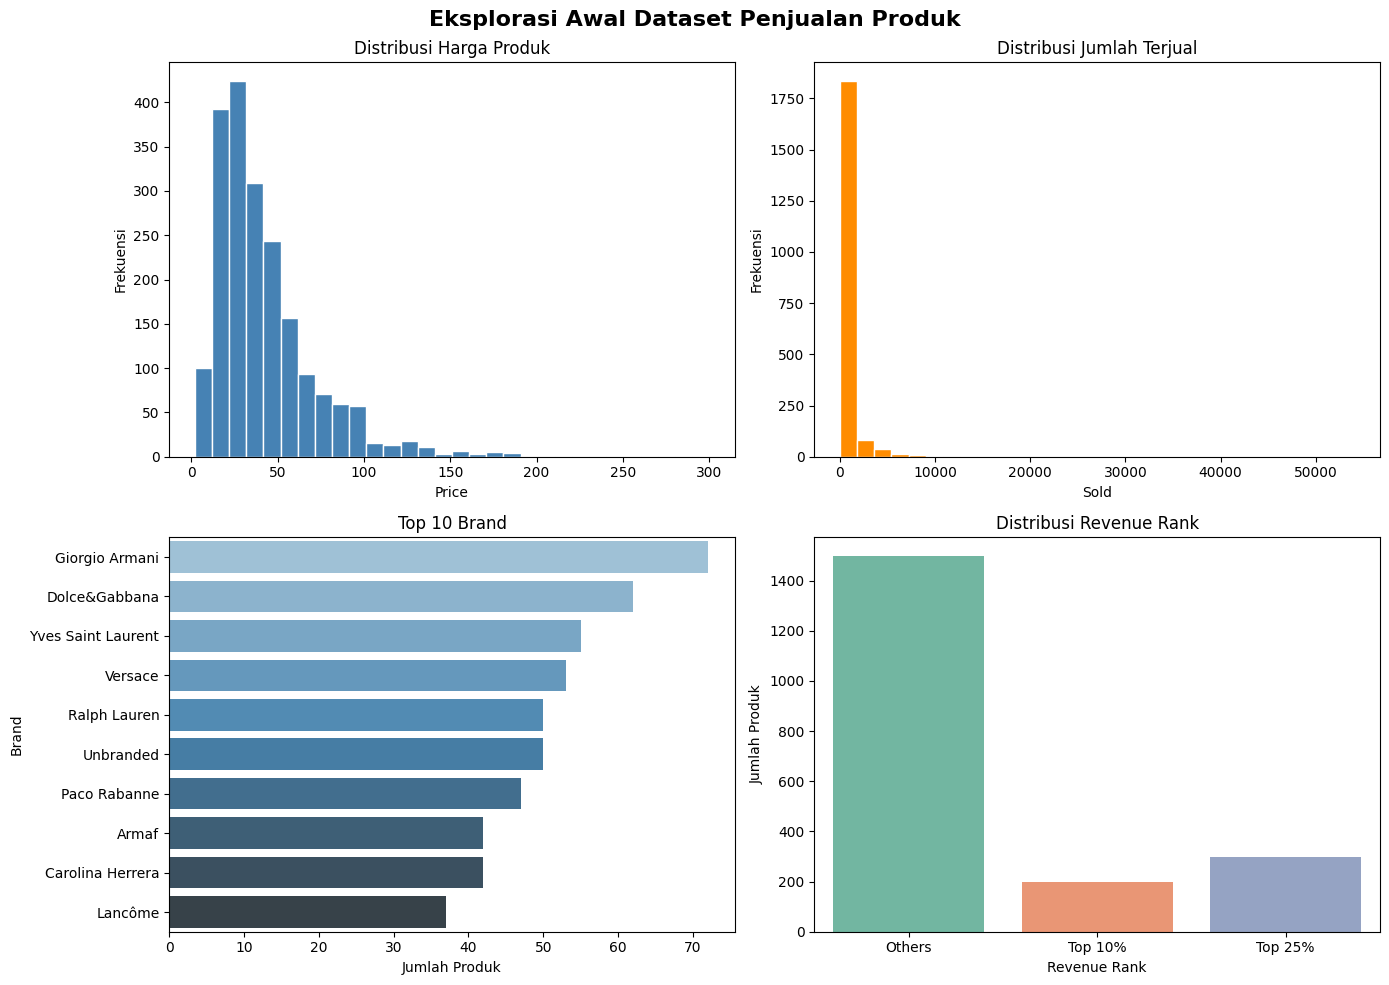

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Eksplorasi Awal Dataset Penjualan Produk', fontsize=16, fontweight='bold')

# a) Distribusi Harga (Price)
axes[0, 0].hist(df['Price'].dropna(), bins=30, color='steelblue', edgecolor='white')
axes[0, 0].set_title('Distribusi Harga Produk')
axes[0, 0].set_xlabel('Price')
axes[0, 0].set_ylabel('Frekuensi')

# b) Distribusi Sold
axes[0, 1].hist(df['Sold'].dropna(), bins=30, color='darkorange', edgecolor='white')
axes[0, 1].set_title('Distribusi Jumlah Terjual')
axes[0, 1].set_xlabel('Sold')
axes[0, 1].set_ylabel('Frekuensi')

# c) Top Brand
top_brand = df['Brand'].value_counts().head(10).reset_index()
top_brand.columns = ['Brand', 'Count']

sns.barplot(data=top_brand, x='Count', y='Brand', hue='Brand', palette='Blues_d', ax=axes[1, 0], legend=False)
axes[1, 0].set_title('Top 10 Brand')
axes[1, 0].set_xlabel('Jumlah Produk')
axes[1, 0].set_ylabel('Brand')

# d) Revenue Rank (FIX: palette disesuaikan otomatis)
rank_order = sorted(df['Revenue_Rank'].dropna().unique())
sns.countplot(data=df, x='Revenue_Rank', hue='Revenue_Rank', palette='Set2', ax=axes[1, 1], legend=False, order=rank_order
)
axes[1, 1].set_title('Distribusi Revenue Rank')
axes[1, 1].set_xlabel('Revenue Rank')
axes[1, 1].set_ylabel('Jumlah Produk')

plt.tight_layout()
plt.show()

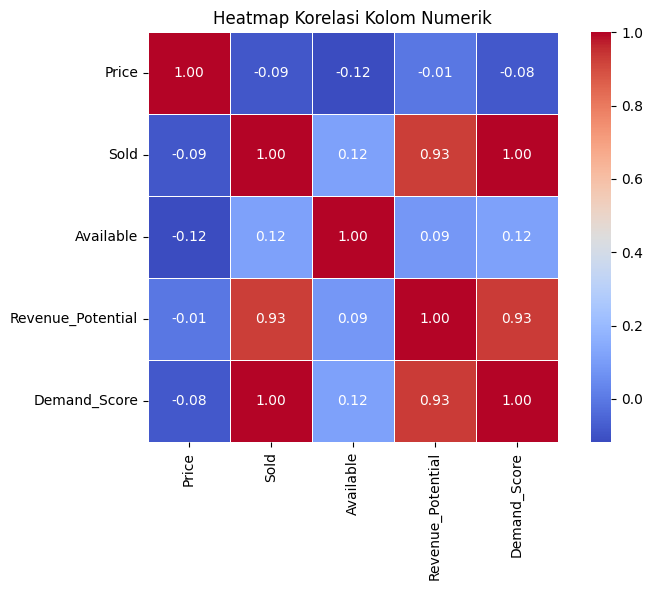


Korelasi fitur dengan Revenue Potential:
Revenue_Potential    1.000000
Demand_Score         0.930209
Sold                 0.929799
Available            0.085222
Price               -0.008445
Name: Revenue_Potential, dtype: float64


In [ ]:
# KORELASI ANTAR FITUR NUMERIK

plt.figure(figsize=(8, 6))
corr = df.select_dtypes(include='number').corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Heatmap Korelasi Kolom Numerik')
plt.tight_layout()
plt.show()

print("\nKorelasi fitur dengan Revenue Potential:")
print(corr['Revenue_Potential'].sort_values(ascending=False))

In [ ]:
print("=" * 60)
print("HIPOTESIS BERDASARKAN HASIL EKSPLORASI DATA")
print("=" * 60)

print('''
  Hipotesis 1:
  Saya berhipotesis bahwa Demand_Score berpengaruh paling tinggi terhadap Revenue_Potential,
  karena korelasinya sangat tinggi (0.93).
  Hal ini menunjukkan bahwa semakin tinggi permintaan, semakin besar potensi revenue yang bisa diperoleh.

  Hipotesis 2:
  Saya berhipotesis bahwa jumlah terjual (Sold) berpengaruh kuat terhadap Revenue_Potential,
  karena korelasinya juga sangat tinggi (0.93).
  Yang artinya, semakin banyak unit terjual maka semakin besar potensi revenue.

  Hipotesis 3:
  Saya berhipotesis bahwa ketersediaan stok (Available) tidak berpengaruh signifikan terhadap Revenue_Potential,
  karena korelasinya sangat rendah (0.085).
  Hal ini menunjukkan bahwa sekadar memiliki stok banyak tidak otomatis meningkatkan revenue.

  Hipotesis 4:
  Saya berhipotesis bahwa harga (Price) tidak berpengaruh terhadap Revenue_Potential,
  karena korelasinya hampir nol (-0.008).
  Ini bisa berarti harga relatif stabil atau tidak menjadi faktor utama dalam menentukan revenue,
  dibandingkan dengan variabel permintaan dan penjualan.

''')

HIPOTESIS BERDASARKAN HASIL EKSPLORASI DATA

  Hipotesis 1:
  Saya berhipotesis bahwa Demand_Score berpengaruh paling tinggi terhadap Revenue_Potential, 
  karena korelasinya sangat tinggi (0.93). 
  Hal ini menunjukkan bahwa semakin tinggi permintaan, semakin besar potensi revenue yang bisa diperoleh.

  Hipotesis 2:
  Saya berhipotesis bahwa jumlah terjual (Sold) berpengaruh kuat terhadap Revenue_Potential,
  karena korelasinya juga sangat tinggi (0.93). 
  Yang artinya, semakin banyak unit terjual maka semakin besar potensi revenue.

  Hipotesis 3:
  Saya berhipotesis bahwa ketersediaan stok (Available) tidak berpengaruh signifikan terhadap Revenue_Potential,
  karena korelasinya sangat rendah (0.085). 
  Hal ini menunjukkan bahwa sekadar memiliki stok banyak tidak otomatis meningkatkan revenue.

  Hipotesis 4:
  Saya berhipotesis bahwa harga (Price) tidak berpengaruh terhadap Revenue_Potential,
  karena korelasinya hampir nol (-0.008).
  Ini bisa berarti harga relatif stabil atau t

# **Exploratory Data Analysis (EDA)**

In [ ]:
print('=== Statistik Numerik ===')
print(df.describe().to_string())

print('\n=== Statistik Kategorikal ===')
print(df.describe(include='object').to_string())

=== Statistik Numerik ===
             Price          Sold    Available  Revenue_Potential  Demand_Score
count  1998.000000   1998.000000  1998.000000       1.998000e+03   1998.000000
mean     43.173769    626.139640    18.236737       1.986833e+04    451.249878
std      32.632128   2458.463389    53.685666       7.691445e+04   1720.077308
min       1.990000      0.000000     0.000000       0.000000e+00      3.700000
25%      21.957500     14.000000     3.000000       5.113175e+02     24.619000
50%      33.995000     49.000000     9.000000       1.811520e+03     51.595500
75%      53.987500    278.750000    10.000000       9.446993e+03    207.022750
max     299.990000  54052.000000   842.000000       1.420246e+06  37843.567000

=== Statistik Kategorikal ===
                 Brand                                                                 Product Gender Product_Type Price_Category Market_Segment Sales_Performance Brand_Popularity        Country Inventory_Status Stock_Turnover Reven

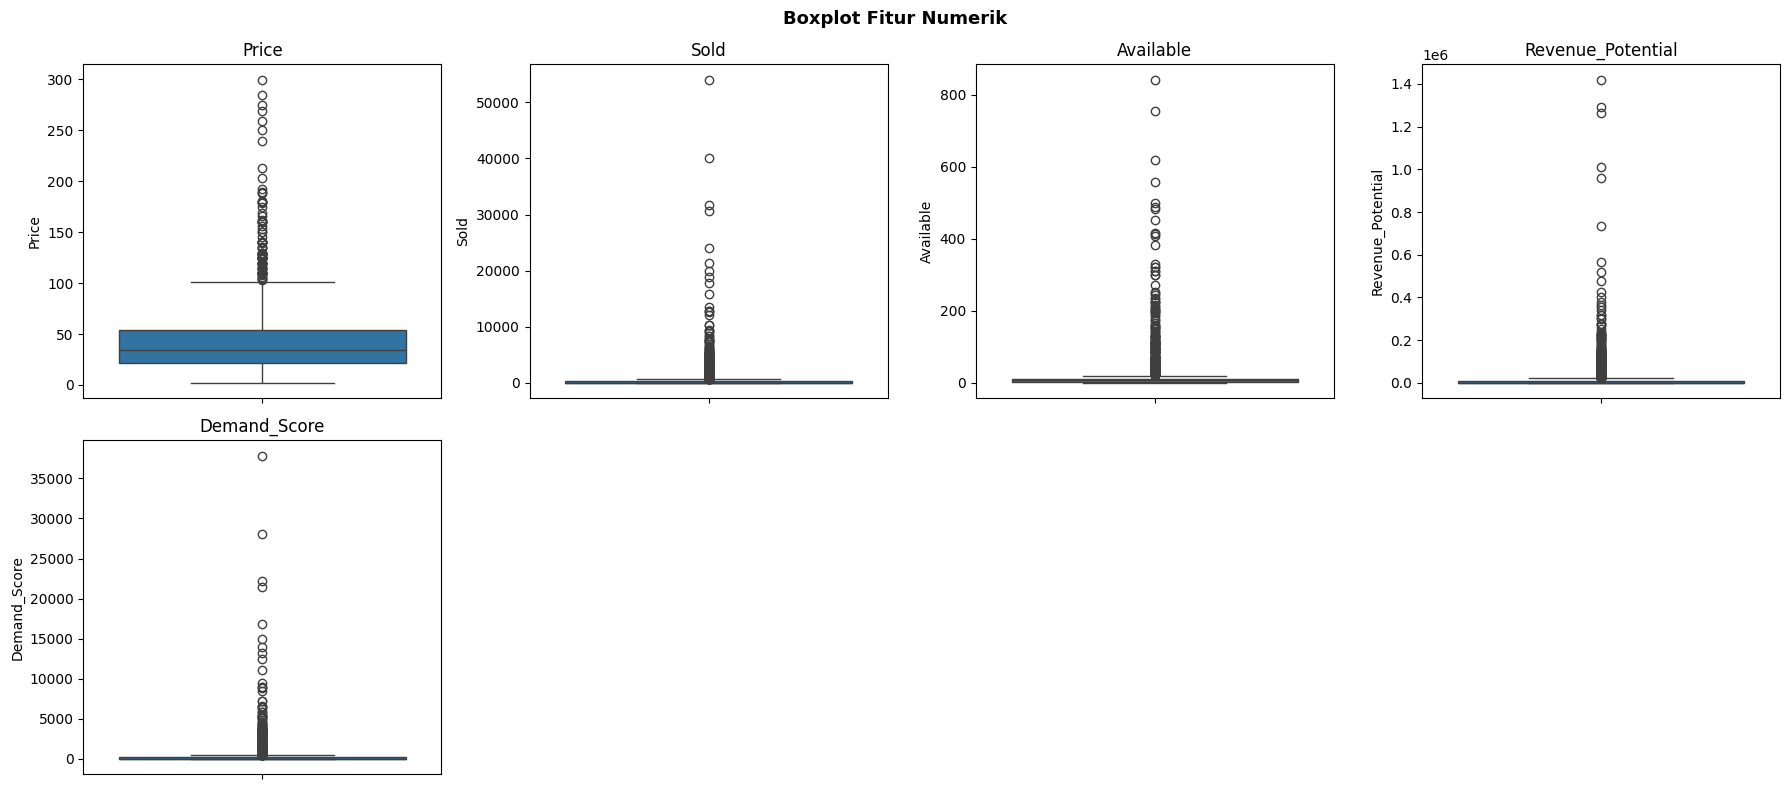

In [ ]:
# Boxplot semua kolom numerik
col_num = df.select_dtypes(include='number').columns
plt.figure(figsize=(18, 8))
for i, col in enumerate(col_num, 1):
    plt.subplot(2, 4, i)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.suptitle('Boxplot Fitur Numerik', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

##**P-VALUE**

In [ ]:
from scipy import stats

Kolom_distribusi_normal = []
Kolom_distribusi_tidak_normal = []
num_cols = df.select_dtypes(include='number')
print("=== Hasil D’Agostino’s K^2 Test ===\n")
for col in num_cols:
    res = stats.normaltest(df[col])
    if res.pvalue > 0.05:
        Kolom_distribusi_normal.append(col)
        print(f"Kolom {col} berdistribusi secara normal")
    else:
        Kolom_distribusi_tidak_normal.append(col)
        print(f"{col} tidak berdistribusi normal")
        print(f"p-value {col}: {res.pvalue}")

=== Hasil D’Agostino’s K^2 Test ===

Price tidak berdistribusi normal
p-value Price: 2.669309914122675e-245
Sold tidak berdistribusi normal
p-value Sold: 0.0
Available tidak berdistribusi normal
p-value Available: 0.0
Revenue_Potential tidak berdistribusi normal
p-value Revenue_Potential: 0.0
Demand_Score tidak berdistribusi normal
p-value Demand_Score: 0.0


## **1. DROP BARIS**
Membuang baris yang memiliki missing value pada kolom penting (`Brand`) serta baris duplikat, sebelum menentukan fitur agar data yang dipakai untuk pemodelan sudah bersih dari awal.

In [ ]:
missing = df.isnull().sum()
print(pd.DataFrame({'Jumlah Missing': missing}))

print('\nJumlah duplikat:', df.duplicated().sum())

                   Jumlah Missing
Brand                           2
Product                         0
Gender                          0
Product_Type                    0
Price                           0
Sold                            0
Available                       0
Revenue_Potential               0
Demand_Score                    0
Price_Category                  0
Market_Segment                  0
Sales_Performance               0
Brand_Popularity                0
Country                         0
Inventory_Status                0
Stock_Turnover                  0
Revenue_Rank                    0

Jumlah duplikat: 0


In [ ]:
# Drop baris yang duplikat (jika ada)
df = df.drop_duplicates()

# Drop baris dengan missing value pada kolom Brand (hanya 2 baris, aman dibuang)
df = df.dropna(subset=['Brand']).reset_index(drop=True)

print('Ukuran data setelah drop baris:', df.shape)
print('Sisa missing value:\n', df.isnull().sum())

Ukuran data setelah drop baris: (1996, 17)
Sisa missing value:
 Brand                0
Product              0
Gender               0
Product_Type         0
Price                0
Sold                 0
Available            0
Revenue_Potential    0
Demand_Score         0
Price_Category       0
Market_Segment       0
Sales_Performance    0
Brand_Popularity     0
Country              0
Inventory_Status     0
Stock_Turnover       0
Revenue_Rank         0
dtype: int64


## **Pembersihan Kategori (Product_Type)**

In [ ]:
df['Product_Type'] = df['Product_Type'].replace({
    'Eau De Toilette': 'EDT',
    'Parfum': 'EDP'
})

product_lower = df['Product'].str.lower()

df.loc[
    product_lower.str.contains(r'eau\s+de\s+(parfum|parfume|perfume)', na=False),
    'Product_Type'
] = 'EDP'

df.loc[
    product_lower.str.contains(r'eau\s+de\s+toilette', na=False),
    'Product_Type'
] = 'EDT'

df.loc[
    product_lower.str.contains(r'eau\s+de\s+cologne', regex=True, na=False),
    'Product_Type'
] = 'Cologne'

mask_unknown = (
    product_lower.str.contains('eau', na=False) & ~df['Product_Type'].isin(['EDP', 'EDT', 'Cologne'])
)
df.loc[mask_unknown, 'Product_Type'] = 'Unknown'

print(df['Product_Type'].value_counts())

Product_Type
EDP        1004
EDT         630
Unknown     185
Cologne     177
Name: count, dtype: int64


/tmp/ipykernel_1323/3548301554.py:9: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  product_lower.str.contains(r'eau\s+de\s+(parfum|parfume|perfume)', na=False),


## **HANDLING OUTLIER**

In [ ]:
df_clean = df.copy()

def handle_outlier_iqr(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    data[col] = data[col].clip(lower_bound, upper_bound)
    return data

num_cols = ['Price', 'Sold', 'Available', 'Revenue_Potential', 'Demand_Score', 'Stock_Turnover']

for col in num_cols:
    if col in df_clean.columns and pd.api.types.is_numeric_dtype(df_clean[col]):
        df_clean = handle_outlier_iqr(df_clean, col)

# Handling khusus Demand_Score (range 0-100)
df_clean['Demand_Score'] = df_clean['Demand_Score'].clip(0, 100)

# Validasi Revenue_Potential = Price x Sold
df_clean['Revenue_Potential'] = df_clean['Price'] * df_clean['Sold']

cat_cols = ['Brand', 'Product', 'Gender', 'Product_Type', 'Price_Category',
            'Market_Segment', 'Sales_Performance', 'Brand_Popularity',
            'Country', 'Inventory_Status', 'Revenue_Rank']

for col in cat_cols:
    if col in df_clean.columns:
        freq = df_clean[col].value_counts(normalize=True)
        rare_labels = freq[freq < 0.01].index
        df_clean[col] = df_clean[col].replace(rare_labels, 'Other')

df_clean.head()

,Brand,Product,Gender,Product_Type,Price,Sold,Available,Revenue_Potential,Demand_Score,Price_Category,Market_Segment,Sales_Performance,Brand_Popularity,Country,Inventory_Status,Stock_Turnover,Revenue_Rank
0,Paco Rabanne,Other,Men,EDT,39.99,118.000,10.0,4718.820,94.597,Mid-Range,Premium,High Seller,High,United States,Medium Stock,Fast,Others
1,Other,Other,Men,Unknown,66.00,21.000,10.0,1386.000,34.500,Mid-Range,Premium,Medium Seller,Low,Other,Medium Stock,Slow,Others
2,Other,Other,Men,EDP,71.49,31.000,4.0,2216.190,43.147,Mid-Range,Premium,Medium Seller,Low,United States,Low Stock,Fast,Others
3,Other,Other,Men,Unknown,17.99,1.000,13.0,17.990,6.097,Budget,Mass Market,Low Seller,Low,United States,Medium Stock,Slow,Others
4,Other,Other,Women,EDP,85.56,674.625,0.0,57720.915,100.000,Luxury,Luxury,High Seller,Medium,United States,Low Stock,Fast,Top 10%


## **2. MENENTUKAN FITUR (X) DAN TARGET (y)**

In [ ]:
cols_to_use = [
    'Brand',
    'Gender',
    'Product_Type',
    'Available',
    'Demand_Score',
    'Market_Segment',
    'Brand_Popularity',
    'Country',
    'Revenue_Potential'
]

df_selected = df_clean[cols_to_use].copy()

print(f"Kolom yang dipilih: {df_selected.columns.to_list()}")
print(f"Ukuran data setelah seleksi kolom: {df_selected.shape}")
df_selected.head()

Kolom yang dipilih: ['Brand', 'Gender', 'Product_Type', 'Available', 'Demand_Score', 'Market_Segment', 'Brand_Popularity', 'Country', 'Revenue_Potential']
Ukuran data setelah seleksi kolom: (1996, 9)


,Brand,Gender,Product_Type,Available,Demand_Score,Market_Segment,Brand_Popularity,Country,Revenue_Potential
0,Paco Rabanne,Men,EDT,10.0,94.597,Premium,High,United States,4718.820
1,Other,Men,Unknown,10.0,34.500,Premium,Low,Other,1386.000
2,Other,Men,EDP,4.0,43.147,Premium,Low,United States,2216.190
3,Other,Men,Unknown,13.0,6.097,Mass Market,Low,United States,17.990
4,Other,Women,EDP,0.0,100.000,Luxury,Medium,United States,57720.915


In [ ]:
X = df_selected.drop('Revenue_Potential', axis=1)
y = df_selected['Revenue_Potential']

print(f"Shape X (fitur): {X.shape}")
print(f"Shape y (target): {y.shape}")
print(f"\nKolom fitur: {list(X.columns)}")

Shape X (fitur): (1996, 8)
Shape y (target): (1996,)

Kolom fitur: ['Brand', 'Gender', 'Product_Type', 'Available', 'Demand_Score', 'Market_Segment', 'Brand_Popularity', 'Country']


## **3. TRAIN-TEST SPLIT**
Target `Revenue_Potential` bersifat kontinu (regresi), sehingga `stratify` tidak digunakan (stratify hanya berlaku untuk target kategorikal/klasifikasi).

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Ukuran X_train: {X_train.shape}")
print(f"Ukuran X_test : {X_test.shape}")
print(f"Ukuran y_train: {y_train.shape}")
print(f"Ukuran y_test : {y_test.shape}")

Ukuran X_train: (1596, 8)
Ukuran X_test : (400, 8)
Ukuran y_train: (1596,)
Ukuran y_test : (400,)


## **4. MENANGANI MISSING VALUE**
Imputasi dilakukan setelah split (fit hanya pada data train) agar tidak terjadi data leakage. Kolom numerik diisi median, kolom kategorikal diisi modus.

In [ ]:
num_features = ['Available', 'Demand_Score']
cat_features = ['Brand', 'Gender', 'Product_Type', 'Market_Segment', 'Brand_Popularity', 'Country']

num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

X_train[num_features] = num_imputer.fit_transform(X_train[num_features])
X_test[num_features]  = num_imputer.transform(X_test[num_features])

X_train[cat_features] = cat_imputer.fit_transform(X_train[cat_features])
X_test[cat_features]  = cat_imputer.transform(X_test[cat_features])

print('Missing value X_train setelah imputasi:\n', X_train.isnull().sum())
print('\nMissing value X_test setelah imputasi:\n', X_test.isnull().sum())

Missing value X_train setelah imputasi:
 Brand               0
Gender              0
Product_Type        0
Available           0
Demand_Score        0
Market_Segment      0
Brand_Popularity    0
Country             0
dtype: int64

Missing value X_test setelah imputasi:
 Brand               0
Gender              0
Product_Type        0
Available           0
Demand_Score        0
Market_Segment      0
Brand_Popularity    0
Country             0
dtype: int64


## **5. ENCODER**
Encoder di-*fit* hanya pada data train, lalu digunakan untuk men-*transform* data test (menghindari data leakage).

- `Market_Segment` dan `Brand_Popularity` → Ordinal Encoding (memiliki urutan tingkatan)
- `Brand`, `Gender`, `Product_Type`, `Country` → One-Hot Encoding (kategori nominal)

In [ ]:
ordinal_map = {
    "Market_Segment":    ["Mass Market", "Premium", "Luxury"],
    "Brand_Popularity":  ["Low", "Medium", "High"]
}

ord_cols = list(ordinal_map.keys())
ord_categories = list(ordinal_map.values())

ord_enc = OrdinalEncoder(categories=ord_categories, handle_unknown='use_encoded_value', unknown_value=-1)
X_train[ord_cols] = ord_enc.fit_transform(X_train[ord_cols])
X_test[ord_cols]  = ord_enc.transform(X_test[ord_cols])

nominal_cols = ["Gender", "Product_Type", "Brand", "Country"]

ohe_m = OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first')
ohe_train = ohe_m.fit_transform(X_train[nominal_cols])
ohe_test  = ohe_m.transform(X_test[nominal_cols])

ohe_cols = ohe_m.get_feature_names_out(nominal_cols)
ohe_train_df = pd.DataFrame(ohe_train, columns=ohe_cols, index=X_train.index)
ohe_test_df  = pd.DataFrame(ohe_test, columns=ohe_cols, index=X_test.index)

X_train_enc = pd.concat([X_train.drop(columns=nominal_cols), ohe_train_df], axis=1)
X_test_enc  = pd.concat([X_test.drop(columns=nominal_cols), ohe_test_df], axis=1)

print(X_train_enc.shape, X_test_enc.shape)
X_train_enc.head()

(1596, 37) (400, 37)


,Available,Demand_Score,Market_Segment,Brand_Popularity,Gender_Women,Product_Type_EDP,Product_Type_EDT,Product_Type_Unknown,Brand_Ariana Grande,Brand_Armaf,...,Brand_Parfums de Marly,Brand_Ralph Lauren,Brand_Unbranded,Brand_Valentino,Brand_Versace,Brand_Victoria's Secret,Brand_Yves Saint Laurent,Country_Hong Kong,Country_Other,Country_United States
1828,10.0,18.826,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
678,10.0,60.097,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1083,3.0,32.065,1.0,2.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
1560,5.0,12.622,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
365,10.0,27.497,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


## **6. SCALING**
`RobustScaler` dipilih karena lebih tahan terhadap outlier residual yang masih mungkin tersisa.

In [ ]:
scaler_m = RobustScaler()

X_train_final = pd.DataFrame(
    scaler_m.fit_transform(X_train_enc),
    columns=X_train_enc.columns,
    index=X_train_enc.index
)
X_test_final = pd.DataFrame(
    scaler_m.transform(X_test_enc),
    columns=X_test_enc.columns,
    index=X_test_enc.index
)

print(f'Ukuran X_train_final : {X_train_final.shape}')
print(f'Ukuran X_test_final  : {X_test_final.shape}')
print(f'Rasio train:test = {len(X_train_final)}:{len(X_test_final)} (80:20)')

Ukuran X_train_final : (1596, 37)
Ukuran X_test_final  : (400, 37)
Rasio train:test = 1596:400 (80:20)


## **MODELING**
Fungsi evaluasi menggunakan metrik regresi (R², RMSE, MAE, MAPE) karena `Revenue_Potential` adalah target kontinu, bukan target klasifikasi.

In [ ]:
eval_results = []

def model_evaluation(name, model, X_tr, X_te, y_tr, y_te):
    y_pred_train = model.predict(X_tr)
    y_pred_test  = model.predict(X_te)

    result = {
        'name': name,
        'R2_train': r2_score(y_tr, y_pred_train),
        'R2_test': r2_score(y_te, y_pred_test),
        'RMSE_test': np.sqrt(mean_squared_error(y_te, y_pred_test)),
        'MAE_test': mean_absolute_error(y_te, y_pred_test),
        'MAPE_test': mean_absolute_percentage_error(y_te, y_pred_test)
    }
    eval_results.append(result)
    print(pd.DataFrame([result]).set_index('name').T)
    return y_pred_test

**Model 1: Ridge Regression**

In [ ]:
model_ridge_alpha_1 = Ridge(alpha=1.0)
model_ridge_alpha_1.fit(X_train_final, y_train)

y_pred_ridge = model_evaluation(
    'Ridge with alpha=1',
    model_ridge_alpha_1,
    X_train_final,
    X_test_final,
    y_train,
    y_test
)

name       Ridge with alpha=1
R2_train         4.739627e-01
R2_test          4.281901e-01
RMSE_test        6.980794e+03
MAE_test         4.898148e+03
MAPE_test        3.916959e+17


In [ ]:
cv_scores = cross_val_score(
    model_ridge_alpha_1,
    X_train_final,
    y_train,
    cv=5,
    scoring='r2'
)

print("Cross Validation R2:", cv_scores)
print("Mean CV R2:", np.mean(cv_scores))

Cross Validation R2: [0.47437861 0.40855816 0.47497935 0.42616158 0.43641383]
Mean CV R2: 0.44409830495378716


In [ ]:
param_grid = {
    'alpha': [0.01, 0.1, 1, 10, 100]
}

grid_ridge = GridSearchCV(
    Ridge(),
    param_grid=param_grid,
    cv=5,
    scoring='r2'
)

grid_ridge.fit(X_train_final, y_train)

print("Best Alpha:", grid_ridge.best_params_['alpha'])
print("Best CV Score:", grid_ridge.best_score_)

Best Alpha: 10
Best CV Score: 0.44739242857895273


In [ ]:
best_ridge = grid_ridge.best_estimator_

y_pred_best_ridge = model_evaluation(
    'Ridge Tuned',
    best_ridge,
    X_train_final,
    X_test_final,
    y_train,
    y_test
)

name        Ridge Tuned
R2_train   4.719849e-01
R2_test    4.352828e-01
RMSE_test  6.937364e+03
MAE_test   4.822254e+03
MAPE_test  3.806947e+17


**RANDOM FOREST REGRESSOR**

In [ ]:
rf = RandomForestRegressor(
    n_estimators=500,
    max_depth=20,
    random_state=42
)

cv_scores = cross_val_score(
    rf,
    X_train_final,
    y_train,
    cv=5,
    scoring='r2'
)

print("Cross Validation R2:", cv_scores)
print("Mean CV R2:", np.mean(cv_scores))

Cross Validation R2: [0.59135759 0.62954263 0.66589679 0.62202874 0.65789984]
Mean CV R2: 0.6333451194349518


In [ ]:
param_grid_rf = {
    'n_estimators': [100, 300, 500],
    'max_depth': [10, 20, None]
}

grid_rf = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid_rf,
    cv=5,
    scoring='r2'
)

grid_rf.fit(X_train_final, y_train)

print("Best Parameters:", grid_rf.best_params_)
print("Best CV Score:", grid_rf.best_score_)

Best Parameters: {'max_depth': 10, 'n_estimators': 500}
Best CV Score: 0.6493115570896387


In [ ]:
best_rf = grid_rf.best_estimator_
best_rf.fit(X_train_final, y_train)

y_pred_best_rf = model_evaluation(
    'Random Forest Tuned',
    best_rf,
    X_train_final,
    X_test_final,
    y_train,
    y_test
)

name       Random Forest Tuned
R2_train          8.418192e-01
R2_test           6.248263e-01
RMSE_test         5.654513e+03
MAE_test          2.700709e+03
MAPE_test         8.090583e+16


**FINAL EVALUATION**

In [ ]:
eval_results_df = pd.DataFrame(eval_results).set_index('name')
print("Model Comparison Table:")
display(eval_results_df.sort_values(by='R2_test', ascending=False))

best_row = eval_results_df.sort_values(by='R2_test', ascending=False).index[0]
print(f"\nModel terbaik berdasarkan R2_test: {best_row}")

Model Comparison Table:


,R2_train,R2_test,RMSE_test,MAE_test,MAPE_test
name,,,,,
Random Forest Tuned,0.841819,0.624826,5654.512516,2700.709478,8.090583e+16
Ridge Tuned,0.471985,0.435283,6937.364283,4822.253656,3.806947e+17
Ridge with alpha=1,0.473963,0.428190,6980.793863,4898.147639,3.916959e+17



Model terbaik berdasarkan R2_test: Random Forest Tuned


In [ ]:
best_model = best_ridge if best_row.startswith('Ridge') else best_rf

os.makedirs('/content/models', exist_ok=True)

joblib.dump(best_model, '/content/models/best_model.joblib')

preprocessor = {
    'scaler': scaler_m,
    'ohe': ohe_m,
    'ordinal': ord_enc,
    'num_imputer': num_imputer,
    'cat_imputer': cat_imputer
}
joblib.dump(preprocessor, '/content/models/preprocessor.joblib')

print("Model tersimpan       : /content/models/best_model.joblib")
print("Preprocessor tersimpan: /content/models/preprocessor.joblib")

Model tersimpan       : /content/models/best_model.joblib
Preprocessor tersimpan: /content/models/preprocessor.joblib


In [ ]:
loaded_model = joblib.load('/content/models/best_model.joblib')
loaded_prep  = joblib.load('/content/models/preprocessor.joblib')

print("Verifikasi isi preprocessor.joblib:")
for k, v in loaded_prep.items():
    print(f"   '{k}' dengan {type(v).__name__}")

print("\nVerifikasi 3 prediksi pertama:")
sample_pred = loaded_model.predict(X_test_final.iloc[:3])
for actual, pred in zip(y_test.values[:3], sample_pred):
    print(f"   Actual: {actual:>12,.2f}  |  Predicted: {pred:>12,.2f}")

Verifikasi isi preprocessor.joblib:
   'scaler' dengan RobustScaler
   'ohe' dengan OneHotEncoder
   'ordinal' dengan OrdinalEncoder
   'num_imputer' dengan SimpleImputer
   'cat_imputer' dengan SimpleImputer

Verifikasi 3 prediksi pertama:
   Actual:     2,649.36  |  Predicted:     5,835.14
   Actual:     1,469.70  |  Predicted:     1,373.03
   Actual:       618.26  |  Predicted:       602.97


KESIMPULAN

---
Random Forest Tuned memang punya R²_test tertinggi (0.62) dibanding Ridge, tapi gap besar dengan R²_train menandakan model belum stabil dan rawan tidak akurat di data yang benar-benar baru/belum terlihat. Sementara Ridge lebih stabi


Rekomendasi

1. Masukkan kembali fitur Sold ke dalam cols_to_use, karena dari analisis korelasi awal fitur ini punya hubungan sangat kuat dengan Revenue_Potential (0.93) namun saat ini dibuang dari seleksi fitur — ini kemungkinan penyebab utama R² rendah pada Ridge dan gap besar pada Random Forest (model "memaksa" pohon menangkap pola yang sebenarnya butuh fitur lebih informatif).
2. Untuk mengatasi overfitting pada Random Forest, batasi kompleksitas model: turunkan max_depth (misal coba 5–10), naikkan min_samples_leaf/min_samples_split, atau lakukan GridSearchCV dengan rentang parameter yang lebih ketat dan tambahkan max_features.
3. Untuk mengatasi underfitting pada Ridge, pertimbangkan menambah fitur relevan (termasuk Sold), atau coba model non-linear dengan regularisasi seperti RandomForestRegressor yang sudah di-tuning ulang, GradientBoostingRegressor, atau XGBoost, yang biasanya lebih baik menangkap hubungan non-linear antar fitur kategorikal/numerik dengan target.
4. Lakukan feature engineering tambahan, misalnya interaksi antar fitur (Demand_Score × Available) atau transformasi log pada target jika distribusinya skewed, untuk membantu model linear menangkap pola lebih baik.
Setelah menambahkan fitur dan menyesuaikan kompleksitas model, bandingkan ulang R²_train vs R²_test — target idealnya selisih di bawah ~0.05–0.1 dengan R²_test di atas 0.7–0.8 agar model bisa dikategorikan goodfit dan layak dipakai untuk prediksi nyata.